In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("./data/data_processed.csv")

In [3]:
data.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành...,Chăm sóc cơ thể,Dạng kem,230000.0,Eucerin,Mỹ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera...",Chăm sóc cơ thể,Dạng kem,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...,Chăm sóc cơ thể,Dạng kem,390000.0,SVR,Pháp,Pháp,unknown,Europe,Chăm sóc cơ thể
4,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Eucerin,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể


In [4]:
data.shape

(1999, 10)

In [5]:
# Create a label encoder object
label_encoder = preprocessing.LabelEncoder()

# Encode labels in the 'Country' column
data['Country'] = label_encoder.fit_transform(data['Country'])
data['Trademark'] = label_encoder.fit_transform(data['Trademark'])
data['General_function'] = label_encoder.fit_transform(data['General_function'])

print(data.head())

                                        Product Name  \
0  Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...   
1  Dung dịch vệ sinh vùng kín Bimunica 250ml dành...   
2  Kem giảm thâm vùng nách, mông, bikini Neothera...   
3  Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...   
4  Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...   

                   Category Dosage Form     Price  Trademark Brand Origin  \
0           Chăm sóc cơ thể         Gel  105000.0         75     Việt Nam   
1           Chăm sóc cơ thể    Dạng kem  230000.0        118           Mỹ   
2           Chăm sóc cơ thể    Dạng kem  139000.0        217     Việt Nam   
3           Chăm sóc cơ thể    Dạng kem  390000.0        375         Pháp   
4  Lăn khử mùi, xịt khử mùi    Dạng bọt   96000.0        118     Việt Nam   

   Country   Rating Continent  General_function  
0       37      5.0      Asia                 0  
1       15      5.0    Europe                 0  
2       37      5.0      Asia                 0  


In [6]:
train_data = data[data['Rating'] != 'unknown']  # Sản phẩm có rating
prediction_data = data[data['Rating'] == 'unknown']  # Sản phẩm chưa có rating

In [7]:
train_data.shape, prediction_data.shape

((1220, 10), (779, 10))

In [8]:
# train_data.to_csv("D:\\FILE_CSV_DATA_MODELING\\train_data.csv")

### 2. Feature Selection

In [9]:
features = ['Price', 'Trademark', 'Country', 'General_function']

### 3. Splitting dataset into X and y

In [10]:
X = train_data[features]
y = train_data["Rating"]
X_test = prediction_data[features]
y_test = prediction_data["Rating"]

In [11]:
X.head()

,Price,Trademark,Country,General_function
0,105000.0,75,37,0
1,230000.0,118,15,0
2,139000.0,217,37,0
4,96000.0,118,37,0
5,132000.0,118,10,1


In [12]:
y.head()

0    5.0
1    5.0
2    5.0
4    5.0
5    5.0
Name: Rating, dtype: object

##### X,y -> X_train, y_train, X_valid, y_valid

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state=0)

In [14]:
X.shape, X_train.shape, X_valid.shape

((1220, 4), (976, 4), (244, 4))

### Model training

- Random Forest
- Gradient Boosting (XGBoost)
- Ridge Regression
- SVR(kernel=rbf)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,  make_scorer, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

### **Random Forest algorithm**

In [16]:
#YOUR CODE HERE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

parameters = {
    'n_estimators' : [100, 200, 300, 400],
    'max_depth': [1, 2, 3, 4]
}
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Huấn luyện mô hình
rf_regressor = RandomForestRegressor(random_state=0)
clf = GridSearchCV(rf_regressor, parameters)
clf.fit(X_train_scaled, y_train)

# Lấy giá trị tốt nhất của siêu tham số
best_params = clf.best_params_
print("Best Parameters:", best_params)

# Khởi tạo mô hình với các siêu tham số tốt nhất
rf_best = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_depth=best_params['max_depth'],
                                random_state=0)

# Huấn luyện lại mô hình với siêu tham số tốt nhất
rf_best.fit(X_train_scaled, y_train)

# Dự đoán với mô hình đã tối ưu
y_pred_best = rf_best.predict(X_valid_scaled)

y_valid = pd.to_numeric(y_valid, errors='coerce')

# Đánh giá mô hình
mae_best = mean_absolute_error(y_valid, y_pred_best)
mse_best = mean_squared_error(y_valid, y_pred_best)

mape = np.mean(np.abs((y_valid - y_pred_best) / y_valid)) * 100
accuracy_best = 100 - mape

print(f"MAE (Best Model): {mae_best}")
print(f"MSE (Best Model): {mse_best}")
print(f"Score (Best Model): {round(accuracy_best, 2)}%")

# Hiển thị kết quả
results_best = pd.DataFrame(zip(y_valid, y_pred_best, y_valid - y_pred_best), 
                            columns=['y_valid', 'y_pred', 'error'])
print(results_best.head(10))


Best Parameters: {'max_depth': 1, 'n_estimators': 100}
MAE (Best Model): 0.14269720342467876
MSE (Best Model): 0.06864955610689483
Score (Best Model): 96.76%
   y_valid    y_pred     error
0      5.0  4.892930  0.107070
1      5.0  4.917068  0.082932
2      5.0  4.897846  0.102154
3      5.0  4.898368  0.101632
4      5.0  4.917152  0.082848
5      5.0  4.916321  0.083679
6      5.0  4.915954  0.084046
7      5.0  4.916746  0.083254
8      5.0  4.890866  0.109134
9      5.0  4.893841  0.106159


<AxesSubplot:>

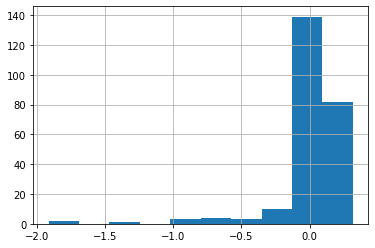

In [17]:
results_best['error'].hist()

### **Gradient Boosting algorithm**

In [18]:
#YOUR CODE HERE

### **Ridge Regression algorithm**

In [19]:
#YOUR CODE HERE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Tìm alpha tối ưu bằng GridSearchCV
params = {'alpha': [0.01, 0.1, 1, 10, 10000]}
ridge_cv = GridSearchCV(Ridge(), params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# Lấy alpha tối ưu
best_alpha = ridge_cv.best_params_['alpha']
print("Best alpha:", best_alpha)

# Tăng khả năng học mối quan hệ phi tuyến
poly = PolynomialFeatures(degree=20)
X_train_poly = poly.fit_transform(X_train_scaled)
X_valid_poly = poly.transform(X_valid_scaled)

# Train lại mô hình với alpha tối ưu
rid_reg_poly = Ridge(alpha=best_alpha)
rid_reg_poly.fit(X_train_poly, y_train)
y_pred_poly = rid_reg_poly.predict(X_valid_poly[:5])



pd.DataFrame({'y' : y_valid.head(), 'y_preds': y_pred_poly})

Best alpha: 10000


c:\Users\admin\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:196: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


,y,y_preds
1758,5.0,4.894199
1391,5.0,4.894199
732,5.0,4.894199
218,5.0,4.894199
1783,5.0,4.894199


### **SVR(kernel=rbf)**

In [20]:
#YOUR CODE HERE
# Đánh giá mô hình

### Cross-validation (baseline model)

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
seed = 2024
models = [
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=seed),
    Ridge(alpha=100),
    #XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=seed)
]

rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

def generate_baseline_results(models, X, y, metrics, cv=5):
    #define k-fold:
    kflod = KFold(n_splits=cv, shuffle=True, random_state=seed)
    entries = []
    for model in models:
        model_name = model.__class__.__name__
        scores = cross_val_score(model, X, y, scoring=metrics, cv=kflod)
        for fold_idx, score in enumerate(scores):
            entries.append((model_name, fold_idx, -score))
    
    cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_id', 'RMSE'])
    
    # Summary result
    mean = cv_df.groupby('model_name')['RMSE'].mean()

    baseline_results = pd.DataFrame(mean)
    baseline_results.columns = ['Mean']
    
    # Sort by RMSE 
    baseline_results.sort_values(by='Mean', ascending=True, inplace=True)
    
    return baseline_results

generate_baseline_results(models, X, y, metrics=rmse_scorer, cv=5)

,Mean
model_name,
Ridge,0.341858
RandomForestRegressor,0.387809
